# Walmart Weekly Sales — Linear Regression

This notebook builds a linear regression model to predict **weekly sales** across 45 Walmart stores using the [Walmart Dataset](https://www.kaggle.com/datasets/yasserh/walmart-dataset) from Kaggle.

**Pipeline overview:**
1. Load & inspect data
2. Feature engineering (date decomposition, encoding)
3. Statistical analysis — identify which features are significantly associated with sales
4. Feature selection based on significance tests
5. Train / test split
6. Train a Linear Regression model
7. Evaluate with R², MAE, and RMSE
8. Interpret coefficients and diagnostic plots

## 1. Setup

Install `kagglehub` to download the dataset directly from Kaggle. You will need a Kaggle account and API key configured, **or** you can upload `Walmart.csv` manually and adjust the `file_path` variable below.

In [1]:
!pip install kagglehub -q

In [21]:
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## 2. Load Data

In [3]:
import kagglehub

path = kagglehub.dataset_download('yasserh/walmart-dataset')
file_path = os.path.join(path, os.listdir(path)[0])

# --- Alternative: upload Walmart.csv manually and set ---
# file_path = 'Walmart.csv'

df = pd.read_csv(file_path)
print(f'Shape: {df.shape}')
df.head()

100%|██████████| 122k/122k [00:00<00:00, 25.4MB/s]

Extracting files...
Shape: (6435, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


## 3. Feature Engineering

The `Date` column is converted to datetime and decomposed into `Week`, `Month`, and `Year` — these capture seasonality effects. `Holiday_Flag` is label-encoded (it is already binary, so this is a no-op, but kept for consistency).

In [4]:
df['Date']  = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Week']  = df['Date'].dt.isocalendar().week.astype(int)
df['Month'] = df['Date'].dt.month
df['Year']  = df['Date'].dt.year
df.drop(columns=['Date'], inplace=True)

le = LabelEncoder()
df['Holiday_Flag'] = le.fit_transform(df['Holiday_Flag'])

print(df.dtypes)
df.describe()

Store             int64
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
Week              int64
Month             int32
Year              int32
dtype: object


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Week,Month,Year
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151,25.818182,6.447552,2010.965035
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885,14.129201,3.238308,0.797019
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000,1.000000,1.000000,2010.000000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000,14.000000,4.000000,2010.000000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000,26.000000,6.000000,2011.000000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000,38.000000,9.000000,2012.000000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000,52.000000,12.000000,2012.000000


## 4. Statistical Analysis

Before modelling, we test each feature's association with `Weekly_Sales` using the appropriate test for its measurement level:

| Variable type | Test | Why |
|---|---|---|
| Continuous (`Temperature`, `Fuel_Price`, `CPI`, `Unemployment`) | Pearson r | Measures linear correlation between two continuous variables |
| Ordinal (`Week`, `Month`) | Kendall's τ | Non-parametric rank correlation — robust to non-normality and ties |
| Binary (`Holiday_Flag`) | Two-sample t-test | Compares means of two groups; Welch's variant used if variances differ (Levene's test) |
| Categorical (`Store`) | One-way ANOVA + Kruskal-Wallis | ANOVA tests equality of means across groups; Kruskal-Wallis is the non-parametric fallback when residuals are non-normal |

Features with **p < 0.05** are retained for modelling.

In [5]:
target      = 'Weekly_Sales'
continuous  = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
ordinal     = ['Week', 'Month']
binary      = ['Holiday_Flag']
categorical = ['Store']

### 4a. Pearson Correlation — Continuous Variables

PEARSON CORRELATION — Continuous Variables
  Temperature          r = -0.0638  p = 0.0000  *
  Fuel_Price           r = +0.0095  p = 0.4478  
  CPI                  r = -0.0726  p = 0.0000  *
  Unemployment         r = -0.1062  p = 0.0000  *


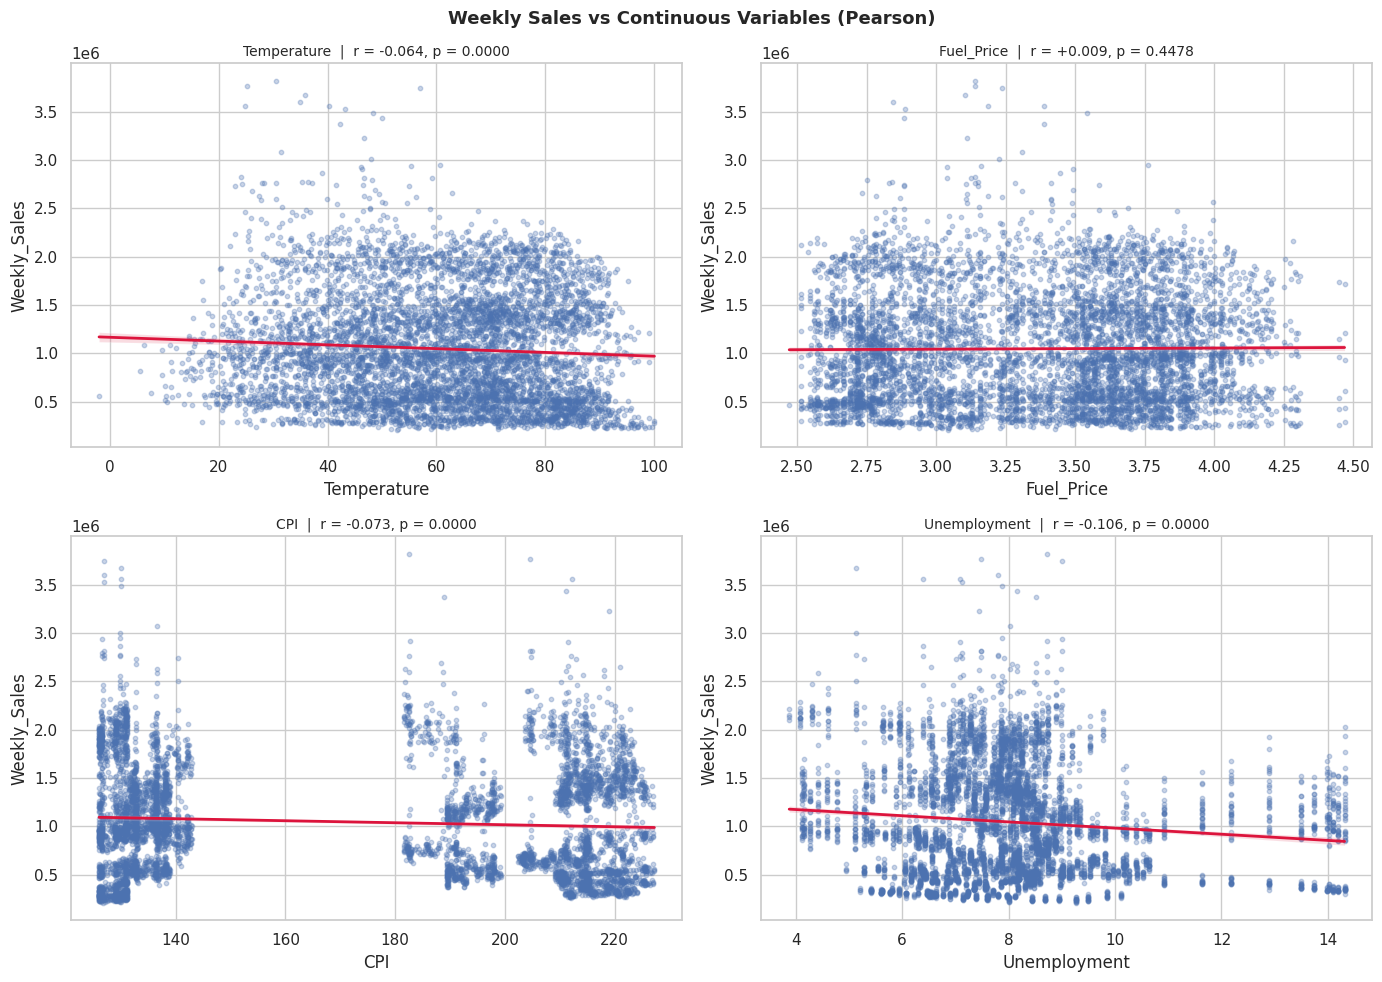

In [6]:
print('=' * 55)
print('PEARSON CORRELATION — Continuous Variables')
print('=' * 55)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Weekly Sales vs Continuous Variables (Pearson)', fontsize=13, fontweight='bold')

for ax, col in zip(axes.flat, continuous):
    r, p = stats.pearsonr(df[col], df[target])
    print(f'  {col:<20} r = {r:+.4f}  p = {p:.4f}  {"*" if p < 0.05 else ""}')
    sns.regplot(data=df, x=col, y=target, ax=ax,
                scatter_kws={'alpha': 0.3, 's': 10},
                line_kws={'color': 'crimson', 'linewidth': 2})
    ax.set_title(f'{col}  |  r = {r:+.3f}, p = {p:.4f}', fontsize=10)

plt.tight_layout()
plt.show()

### 4b. Kendall's τ — Ordinal Variables

KENDALL'S TAU — Ordinal Variables
  Week                 tau = +0.0328  p = 0.0001  *
  Month                tau = +0.0354  p = 0.0000  *


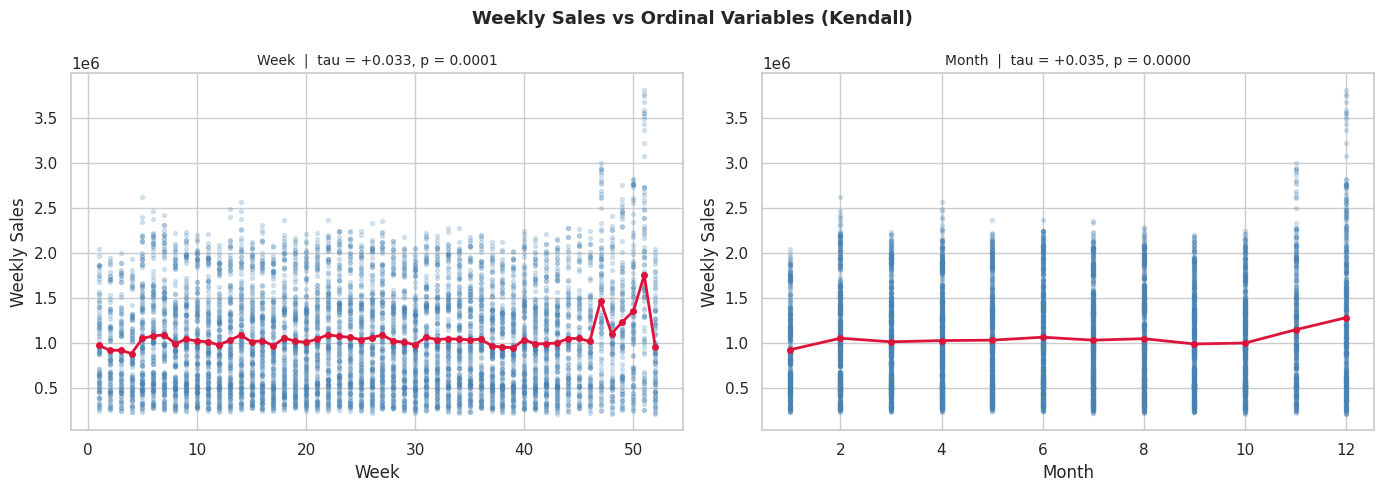

In [7]:
print('=' * 55)
print("KENDALL'S TAU — Ordinal Variables")
print('=' * 55)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Weekly Sales vs Ordinal Variables (Kendall)', fontsize=13, fontweight='bold')

for ax, col in zip(axes, ordinal):
    tau, p = stats.kendalltau(df[col], df[target])
    print(f'  {col:<20} tau = {tau:+.4f}  p = {p:.4f}  {"*" if p < 0.05 else ""}')
    mean_sales = df.groupby(col)[target].mean().reset_index()
    ax.scatter(df[col], df[target], alpha=0.2, s=8, color='steelblue')
    ax.plot(mean_sales[col], mean_sales[target], color='crimson', linewidth=2, marker='o', markersize=4)
    ax.set_title(f'{col}  |  tau = {tau:+.3f}, p = {p:.4f}', fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel('Weekly Sales')

plt.tight_layout()
plt.show()

### 4c. Two-Sample t-Test — Holiday Flag

TWO-SAMPLE T-TEST — Holiday_Flag
  Levene's test: p = 0.0012 -> unequal variances (Welch)
  t = -2.6801,  p = 0.0076  *
  Mean non-holiday: $1,041,256  |  Mean holiday: $1,122,888


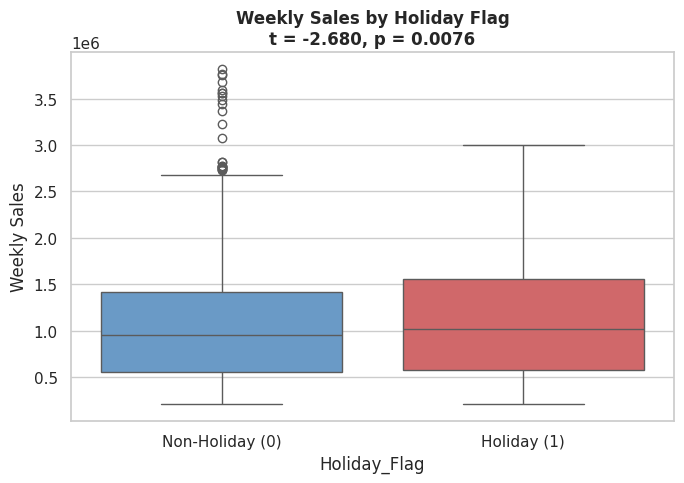

In [8]:
print('=' * 55)
print('TWO-SAMPLE T-TEST — Holiday_Flag')
print('=' * 55)

group0 = df[df['Holiday_Flag'] == 0][target]
group1 = df[df['Holiday_Flag'] == 1][target]

lev_stat, lev_p = stats.levene(group0, group1)
equal_var = lev_p > 0.05
t_stat, p_ttest = stats.ttest_ind(group0, group1, equal_var=equal_var)

print(f"  Levene's test: p = {lev_p:.4f} -> {'equal variances' if equal_var else 'unequal variances (Welch)'}")
print(f'  t = {t_stat:.4f},  p = {p_ttest:.4f}  {"*" if p_ttest < 0.05 else ""}')
print(f'  Mean non-holiday: ${group0.mean():,.0f}  |  Mean holiday: ${group1.mean():,.0f}')

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='Holiday_Flag', y=target, palette=['#5B9BD5', '#E15759'], ax=ax)
ax.set_xticklabels(['Non-Holiday (0)', 'Holiday (1)'])
ax.set_title(f'Weekly Sales by Holiday Flag\nt = {t_stat:.3f}, p = {p_ttest:.4f}', fontweight='bold')
ax.set_ylabel('Weekly Sales')
plt.tight_layout()
plt.show()

### 4d. ANOVA + Kruskal-Wallis — Store

ANOVA + KRUSKAL-WALLIS — Store
  ANOVA:          F = 1613.2995,  p = 0.0000  *
  Effect size eta2 = 0.9174 (large)
  Shapiro-Wilk on residuals: p = 0.0000
  -> Non-normal residuals: reporting Kruskal-Wallis
  Kruskal-Wallis: H = 6144.3229,  p = 0.0000  *


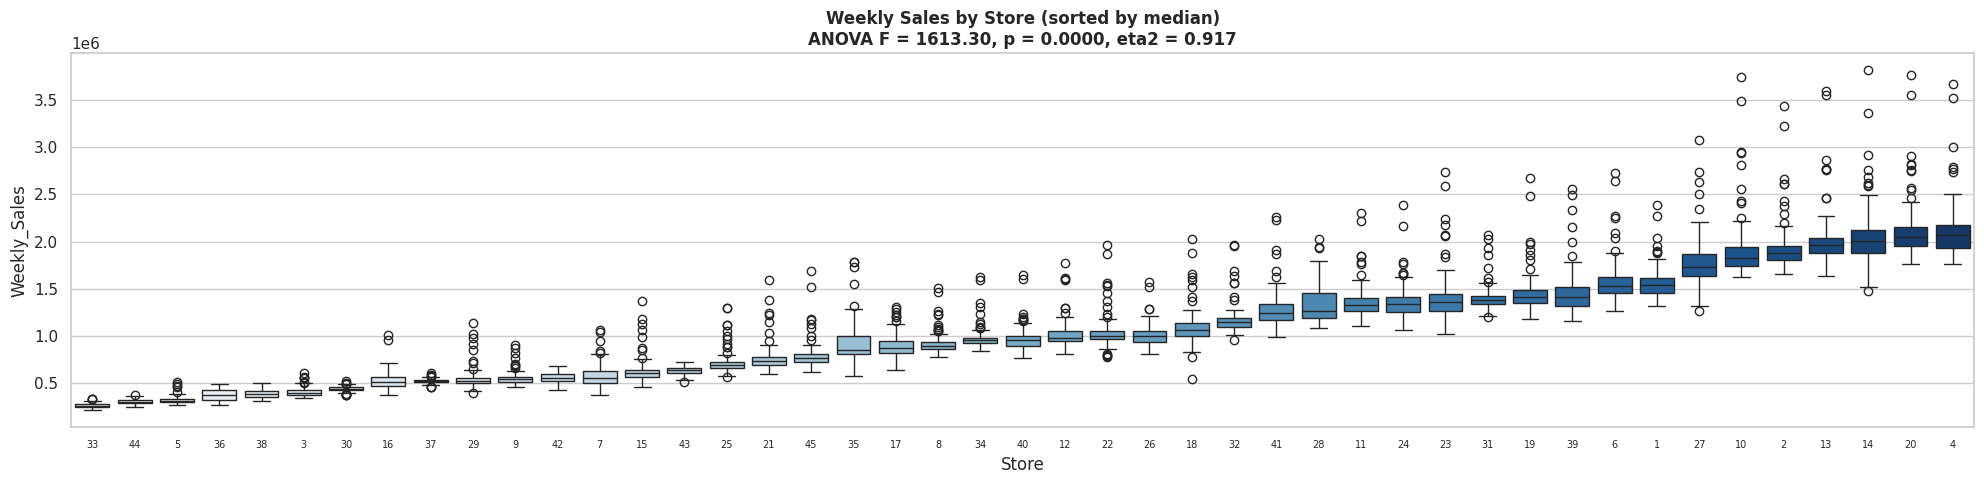

In [9]:
print('=' * 55)
print('ANOVA + KRUSKAL-WALLIS — Store')
print('=' * 55)

groups = [g[target].values for _, g in df.groupby('Store')]
f_stat, p_anova = stats.f_oneway(*groups)

grand_mean = df[target].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in [pd.Series(g) for g in groups])
ss_total   = sum((df[target] - grand_mean) ** 2)
eta_sq     = ss_between / ss_total

print(f'  ANOVA:          F = {f_stat:.4f},  p = {p_anova:.4f}  {"*" if p_anova < 0.05 else ""}')
print(f"  Effect size eta2 = {eta_sq:.4f} ({'large' if eta_sq > 0.14 else 'medium' if eta_sq > 0.06 else 'small'})")

residuals = df[target] - df.groupby('Store')[target].transform('mean')
_, p_shapiro = stats.shapiro(residuals.sample(500, random_state=42))
print(f'  Shapiro-Wilk on residuals: p = {p_shapiro:.4f}')

if p_shapiro < 0.05:
    h_stat, p_kruskal = stats.kruskal(*groups)
    print(f'  -> Non-normal residuals: reporting Kruskal-Wallis')
    print(f'  Kruskal-Wallis: H = {h_stat:.4f},  p = {p_kruskal:.4f}  {"*" if p_kruskal < 0.05 else ""}')

store_order = df.groupby('Store')[target].median().sort_values().index
fig, ax = plt.subplots(figsize=(20, 5))
sns.boxplot(data=df, x='Store', y=target, order=store_order, palette='Blues', ax=ax)
ax.set_title(f'Weekly Sales by Store (sorted by median)\nANOVA F = {f_stat:.2f}, p = {p_anova:.4f}, eta2 = {eta_sq:.3f}', fontweight='bold')
ax.tick_params(axis='x', labelsize=7)
plt.tight_layout()
plt.show()

### 4e. Summary Table

In [10]:
print('=' * 55)
print('SUMMARY')
print('=' * 55)
print(f'{"Variable":<20} {"Test":<22} {"Statistic":>12}  {"p-value":>10}  Sig.')
print('-' * 70)
for col in continuous:
    r, p = stats.pearsonr(df[col], df[target])
    print(f'{col:<20} {"Pearson r":<22} {r:>+12.4f}  {p:>10.4f}  {"*" if p < 0.05 else ""}')
for col in ordinal:
    tau, p = stats.kendalltau(df[col], df[target])
    print(f'{col:<20} {"Kendall tau":<22} {tau:>+12.4f}  {p:>10.4f}  {"*" if p < 0.05 else ""}')
print(f'{"Holiday_Flag":<20} {"Two-sample t-test":<22} {t_stat:>+12.4f}  {p_ttest:>10.4f}  {"*" if p_ttest < 0.05 else ""}')
print(f'{"Store":<20} {"ANOVA F":<22} {f_stat:>+12.4f}  {p_anova:>10.4f}  {"*" if p_anova < 0.05 else ""}')

SUMMARY
Variable             Test                      Statistic     p-value  Sig.
----------------------------------------------------------------------
Temperature          Pearson r                   -0.0638      0.0000  *
Fuel_Price           Pearson r                   +0.0095      0.4478  
CPI                  Pearson r                   -0.0726      0.0000  *
Unemployment         Pearson r                   -0.1062      0.0000  *
Week                 Kendall tau                 +0.0328      0.0001  *
Month                Kendall tau                 +0.0354      0.0000  *
Holiday_Flag         Two-sample t-test           -2.6801      0.0076  *
Store                ANOVA F                  +1613.2995      0.0000  *


## 5. Feature Selection

Only features with **p < 0.05** in their respective tests are retained. `Store` is one-hot encoded since it is a nominal categorical variable — `drop_first=True` drops one dummy to avoid perfect multicollinearity (the dummy trap).

In [11]:
sig_cols = []

for col in continuous + ordinal:
    if col in continuous:
        _, p = stats.pearsonr(df[col], df[target])
    else:
        _, p = stats.kendalltau(df[col], df[target])
    if p < 0.05:
        sig_cols.append(col)
    print(f'  {col:<20} p = {p:.4f}  {"-> KEEP" if p < 0.05 else "-> DROP"}')

if p_ttest < 0.05:
    sig_cols.append('Holiday_Flag')
print(f'  {"Holiday_Flag":<20} p = {p_ttest:.4f}  {"-> KEEP" if p_ttest < 0.05 else "-> DROP"}')

if p_anova < 0.05:
    sig_cols.append('Store')
print(f'  {"Store":<20} p = {p_anova:.4f}  {"-> KEEP" if p_anova < 0.05 else "-> DROP"}')

print(f'\nRetained features: {sig_cols}')

df_model = df[sig_cols + [target]].copy()

if 'Store' in sig_cols:
    df_model = pd.get_dummies(df_model, columns=['Store'], drop_first=True)

print(f'Shape after encoding: {df_model.shape}')

  Temperature          p = 0.0000  -> KEEP
  Fuel_Price           p = 0.4478  -> DROP
  CPI                  p = 0.0000  -> KEEP
  Unemployment         p = 0.0000  -> KEEP
  Week                 p = 0.0001  -> KEEP
  Month                p = 0.0000  -> KEEP
  Holiday_Flag         p = 0.0076  -> KEEP
  Store                p = 0.0000  -> KEEP

Retained features: ['Temperature', 'CPI', 'Unemployment', 'Week', 'Month', 'Holiday_Flag', 'Store']
Shape after encoding: (6435, 51)


## 6. Train / Test Split

An 80/20 split with a fixed `random_state` for reproducibility. Stratification is not needed for regression targets.

In [12]:
X = df_model.drop(columns=[target])
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}  |  y_test: {y_test.shape}')

X_train: (5148, 50)  |  X_test: (1287, 50)
y_train: (5148,)  |  y_test: (1287,)


## 7a. Train Linear Regression

Features are standardized with `StandardScaler` (mean = 0, std = 1) so that coefficients are on the same scale and directly comparable. The scaler is **fit only on the training set** — we then apply those same training statistics when transforming the test set. Fitting on test data would leak information and give an overly optimistic evaluation.

Ordinary Least Squares (OLS) linear regression then finds the hyperplane that minimizes the sum of squared residuals across all training samples.

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print('Model trained.')

Model trained.


## 7b. Train Polynomial Regression (Baseline Model 2)

In [18]:
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])

poly_model.fit(X_train, y_train)

print('Polynomial regression model trained.')

Polynomial regression model trained.


## 8a. Logistic Regression Evaluation

| Metric | Formula | Interpretation |
|---|---|---|
| **R²** | 1 - SS_res / SS_tot | Proportion of variance explained. 1.0 = perfect, 0 = no better than predicting the mean. |
| **MAE** | mean(|y - y_hat|) | Average absolute dollar error per prediction. Easy to interpret directly. |
| **RMSE** | sqrt(mean((y - y_hat)²)) | Like MAE but penalises large errors more heavily. RMSE > MAE means some predictions have significant outlier errors. |

Comparing **Train R²** vs **Test R²** is a quick overfitting check — values close together indicate the model generalises well.

In [14]:
y_pred_train = model.predict(X_train_scaled)
y_pred_test  = model.predict(X_test_scaled)

train_r2  = r2_score(y_train, y_pred_train)
test_r2   = r2_score(y_test,  y_pred_test)
test_mae  = mean_absolute_error(y_test, y_pred_test)
test_rmse = mean_squared_error(y_test, y_pred_test) ** 0.5

print('=' * 40)
print('LINEAR REGRESSION — Results')
print('=' * 40)
print(f'  Train R²:   {train_r2:.4f}')
print(f'  Test  R²:   {test_r2:.4f}')
print(f'  Test  MAE:  ${test_mae:,.0f}')
print(f'  Test  RMSE: ${test_rmse:,.0f}')

LINEAR REGRESSION — Results
  Train R²:   0.9272
  Test  R²:   0.9256
  Test  MAE:  $96,163
  Test  RMSE: $154,818


## 8b. Polynomial Regression Evaluation

In [19]:
y_pred_train_poly = poly_model.predict(X_train)
y_pred_test_poly  = poly_model.predict(X_test)

poly_train_r2  = r2_score(y_train, y_pred_train_poly)
poly_test_r2   = r2_score(y_test, y_pred_test_poly)
poly_test_mae  = mean_absolute_error(y_test, y_pred_test_poly)
poly_test_rmse = mean_squared_error(y_test, y_pred_test_poly) ** 0.5

print('=' * 40)
print('POLYNOMIAL REGRESSION (DEGREE 2) — Results')
print('=' * 40)
print(f'  Train R²:   {poly_train_r2:.4f}')
print(f'  Test  R²:   {poly_test_r2:.4f}')
print(f'  Test  MAE:  ${poly_test_mae:,.0f}')
print(f'  Test  RMSE: ${poly_test_rmse:,.0f}')

POLYNOMIAL REGRESSION (DEGREE 2) — Results
  Train R²:   0.9563
  Test  R²:   0.9484
  Test  MAE:  $78,223
  Test  RMSE: $128,887


## 8c. Compare Linear vs Polynomial Regression

In [20]:
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Polynomial Regression (Degree 2)'],
    'Train R²': [train_r2, poly_train_r2],
    'Test R²': [test_r2, poly_test_r2],
    'Test MAE': [test_mae, poly_test_mae],
    'Test RMSE': [test_rmse, poly_test_rmse]
})

comparison_df

,Model,Train R²,Test R²,Test MAE,Test RMSE
0,Linear Regression,0.927193,0.925599,96163.214708,154817.844437
1,Polynomial Regression (Degree 2),0.956257,0.948435,78223.055291,128887.382595


Polynomial regression performed better than linear regression because it captured nonlinear relationships in the sales data. It improved test R² from 0.9256 to 0.9484 and reduced both MAE and RMSE. Since the train and test R² values are close, the model does not appear to overfit strongly.

## 8d. Ridge Regression

In [22]:
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

ridge_params = {
    'ridge__alpha': [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_params,
    cv=5,
    scoring='r2'
)

ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_

print("Best alpha:", ridge_grid.best_params_['ridge__alpha'])
print("Ridge regression model trained.")

Best alpha: 0.1
Ridge regression model trained.


## 8e. Evaluate Ridge Regression

In [23]:
# Evaluate Ridge Regression
y_pred_train_ridge = best_ridge.predict(X_train)
y_pred_test_ridge = best_ridge.predict(X_test)

ridge_train_r2 = r2_score(y_train, y_pred_train_ridge)
ridge_test_r2 = r2_score(y_test, y_pred_test_ridge)
ridge_test_mae = mean_absolute_error(y_test, y_pred_test_ridge)
ridge_test_rmse = mean_squared_error(y_test, y_pred_test_ridge) ** 0.5

print("=" * 40)
print("RIDGE REGRESSION — Results")
print("=" * 40)
print(f"Train R²:   {ridge_train_r2:.4f}")
print(f"Test R²:    {ridge_test_r2:.4f}")
print(f"Test MAE:   ${ridge_test_mae:,.0f}")
print(f"Test RMSE:  ${ridge_test_rmse:,.0f}")

RIDGE REGRESSION — Results
Train R²:   0.9272
Test R²:    0.9256
Test MAE:   $96,161
Test RMSE:  $154,820


## 8f. Compare Linear vs Polynomial vs Ridge Regression

In [24]:
comparison_df = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Polynomial Regression (Degree 2)',
        'Ridge Regression'
    ],
    'Train R²': [
        train_r2,
        poly_train_r2,
        ridge_train_r2
    ],
    'Test R²': [
        test_r2,
        poly_test_r2,
        ridge_test_r2
    ],
    'Test MAE': [
        test_mae,
        poly_test_mae,
        ridge_test_mae
    ],
    'Test RMSE': [
        test_rmse,
        poly_test_rmse,
        ridge_test_rmse
    ]
})

comparison_df

,Model,Train R²,Test R²,Test MAE,Test RMSE
0,Linear Regression,0.927193,0.925599,96163.214708,154817.844437
1,Polynomial Regression (Degree 2),0.956257,0.948435,78223.055291,128887.382595
2,Ridge Regression,0.927193,0.925597,96160.900296,154820.192225


Among the three models tested so far, polynomial regression performed best. It achieved the highest Test R² and the lowest MAE and RMSE, indicating that allowing moderate nonlinear relationships improved sales prediction.

## Overfitting

*   Linear Regression: no strong overfitting
*   Ridge Regression: no strong overfitting
*   Polynomial Regression: slightly higher train R², but still strong test R² and a small enough gap

Based on the train and test R² values, none of the three models showed severe overfitting. Although polynomial regression is more flexible, it still generalized well on the test data.

## 9. Coefficients

Because features were standardized, each coefficient represents the change in `Weekly_Sales` per **one standard deviation** increase in that feature — magnitudes are directly comparable across all variables.

Store dummy variables are expected to dominate since store identity (size, location, demographics) is far more predictive than week-to-week economic indicators.

In [15]:
coef_df = pd.DataFrame({
    'Feature':     X_train.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(coef_df.to_string(index=False))

     Feature    Coefficient
    Store_44 -197895.643109
    Store_33 -190227.755136
     Store_5 -185882.080910
       Month  174684.781648
    Store_30 -169261.829459
    Store_36 -169247.829263
    Store_16 -165603.797576
     Store_3 -165359.141276
    Store_38 -162555.441522
     Store_7 -159339.413708
    Store_29 -157651.773350
    Store_37 -152426.466912
     Store_9 -151407.681457
    Store_15 -150424.796528
    Store_42 -148898.449430
    Store_43 -135212.442096
    Store_25 -130779.141063
        Week -123475.005505
    Store_45 -119648.731160
    Store_21 -113939.875831
    Store_17 -113281.208103
    Store_40 -107807.878244
     Store_8 -101258.144728
    Store_35  -98400.466670
    Store_26  -93900.059106
    Store_34  -91218.916642
    Store_22  -87718.918129
    Store_20   76425.051690
    Store_18  -75527.572617
    Store_12  -71121.843707
     Store_4   66993.513534
    Store_32  -64519.439928
    Store_14   62281.025907
    Store_13   56645.075421
    Store_41  -52748

## 10. Diagnostic Plots

**Residuals vs Predicted** — checks model assumptions. Ideally a flat, random cloud centred on zero. A funnel shape indicates *heteroscedasticity* (variance grows with prediction size); a curve suggests a non-linear relationship the model has not captured.

**Actual vs Predicted** — each point is one test observation. Points should cluster tightly along the diagonal (perfect prediction line). Scatter away from it represents prediction error.

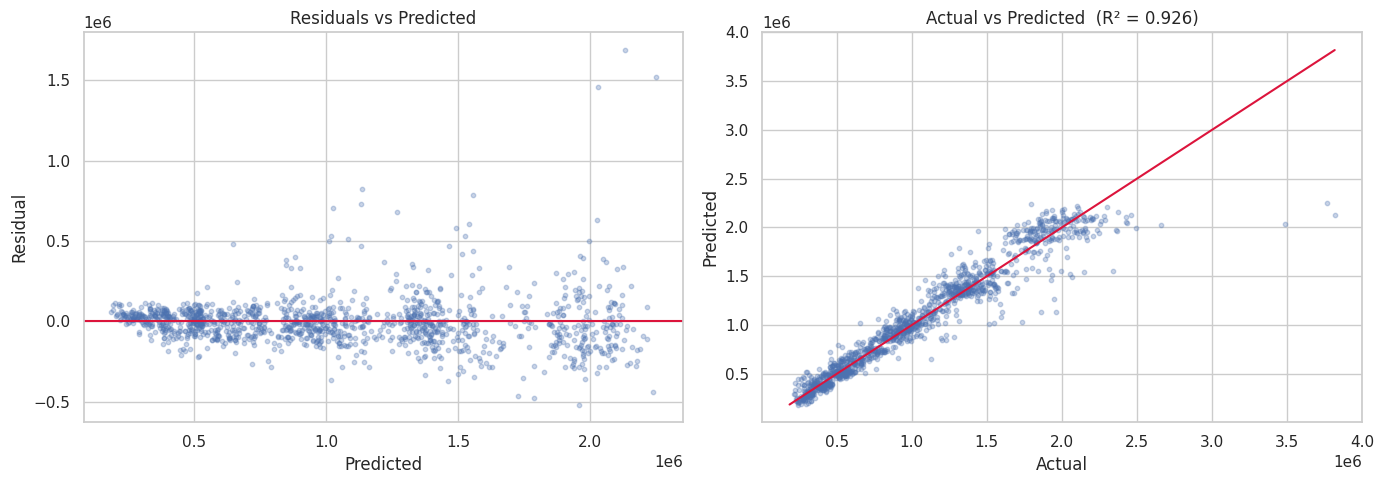

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_test, y_test - y_pred_test, alpha=0.3, s=10)
axes[0].axhline(0, color='crimson', linewidth=1.5)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

axes[1].scatter(y_test, y_pred_test, alpha=0.3, s=10)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
axes[1].plot(lims, lims, color='crimson', linewidth=1.5)
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Actual vs Predicted  (R² = {test_r2:.3f})')

plt.tight_layout()
plt.show()